<a href="https://colab.research.google.com/github/himanshusar123/-Machine-Learning-Quiz-Classification-or-Regression-/blob/main/Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Student Risk Prediction Project

from google.colab import files

uploaded = files.upload()

Saving Student_At_Risk_Prediction (1).csv to Student_At_Risk_Prediction (1).csv


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [6]:
df = pd.read_csv(
    "Student_At_Risk_Prediction (1).csv"
)

In [10]:
df.head()

,Student_Age,Attendance_Percentage,Study_Hours_Per_Week,Assignments_Submitted,Mock_Test_Score,At_Risk
0,23,69,20,3,42,0
1,20,57,20,8,35,0
2,29,41,30,1,28,1
3,27,88,27,9,32,0
4,24,52,26,3,47,0


In [7]:
df["At_Risk"] = df["At_Risk"].map(
    {
        "No":0,
        "Yes":1
    }
)

In [9]:
df.head()

,Student_Age,Attendance_Percentage,Study_Hours_Per_Week,Assignments_Submitted,Mock_Test_Score,At_Risk
0,23,69,20,3,42,0
1,20,57,20,8,35,0
2,29,41,30,1,28,1
3,27,88,27,9,32,0
4,24,52,26,3,47,0


In [11]:
X = df[
    [
        "Student_Age",
        "Attendance_Percentage",
        "Study_Hours_Per_Week",
        "Assignments_Submitted",
        "Mock_Test_Score"
    ]
]

In [12]:
y = df["At_Risk"]

In [13]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [14]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [15]:
model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [16]:
y_pred=model.predict(X_test)

In [18]:
accuracy=accuracy_score(y_test,y_pred)
print(
    "Accuracy:",
    round(accuracy*100,2),
    "%"
)

Accuracy: 97.8 %


In [19]:
df["At_Risk"].value_counts()

,count
At_Risk,
0,2255
1,245


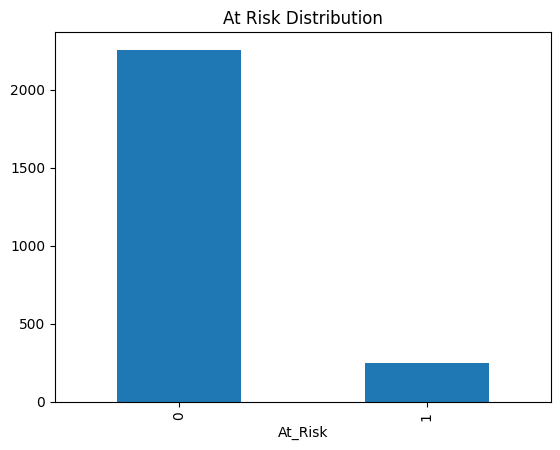

In [22]:
df["At_Risk"].value_counts().plot(
    kind="bar"
)

plt.title("At Risk Distribution")

plt.show()

In [23]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[454   1]
 [ 10  35]]


In [24]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       455
           1       0.97      0.78      0.86        45

    accuracy                           0.98       500
   macro avg       0.98      0.89      0.93       500
weighted avg       0.98      0.98      0.98       500



In [25]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
3,Assignments_Submitted,0.290071
1,Attendance_Percentage,0.271471
4,Mock_Test_Score,0.245474
2,Study_Hours_Per_Week,0.134639
0,Student_Age,0.058346


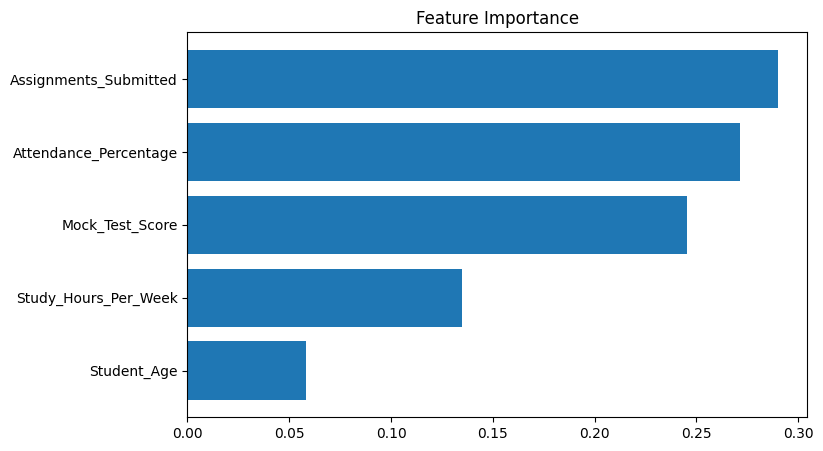

In [26]:
import matplotlib.pyplot as plt

importance = importance.sort_values(
    by="Importance"
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Feature Importance"
)

plt.show()

In [29]:
DecisionTreeClassifier()

DecisionTreeClassifier()

In [30]:
RandomForestClassifier()

RandomForestClassifier()